f=1, g=0, crack: 0 degrees

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Settings
torch.set_default_dtype(torch.float64)   # use double for better derivative precision
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Domain: square [-1,1]^2 with crack along y=x starting from origin
X_MIN, X_MAX = -1.0, 1.0
Y_MIN, Y_MAX = -1.0, 1.0

# Training hyperparams
N_f = 500       # collocation points
N_b = 500  # boundary points on outer square
epochs = 3000
lam, lam_up, lam_down = 1e3, 3.0, 0.7

In [3]:
# Neural network
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = torch.tanh
        # init
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, inp):
        z = inp
        for layer in self.net[:-1]:
            z = self.activation(layer(z))
        z = self.net[-1](z)  # no activation on last
        return z

# model
layers = [3, 30, 30, 1]
model = MLP(layers).to(device)

In [4]:
def compute_phi(x, y):
    eps = 1e-12
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=eps))
    phi = torch.sqrt(0.5 * (r - x))
    return phi.view(-1, 1)

def compute_phi_derivs(x, y):
    eps = 1e-12
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=eps))
    phi_x = (-0.5) * (0.5**0.5) * torch.sqrt(r - x) / r
    phi_y = (0.25) * (2**0.5) * (y/r)/ torch.sqrt(r - x)

    return phi_x.reshape(-1,1), phi_y.reshape(-1,1)

def first_derivs(model, x, y):
    phi = compute_phi(x, y)
    inp = torch.cat([x, y, phi], dim=1).requires_grad_(True)

    U = model(inp).view(-1, 1)

    grads = torch.autograd.grad(
        outputs=U.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    return U, inp, grads[:,0:1], grads[:,1:2], grads[:,2:3]

def second_partials_U(inp, U_x, U_y, U_z):

    grad_Ux = torch.autograd.grad(
        outputs=U_x.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    grad_Uy = torch.autograd.grad(
        outputs=U_y.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    grad_Uz = torch.autograd.grad(
        outputs=U_z.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    U_xx = grad_Ux[:, 0:1]
    U_xy = grad_Ux[:, 1:2]
    U_xz = grad_Ux[:, 2:3]

    U_yy = grad_Uy[:, 1:2]
    U_yz = grad_Uy[:, 2:3]

    U_zz = grad_Uz[:, 2:3]

    return U_xx, U_yy, U_xz, U_yz, U_zz

def laplace_u(model, x, y):
    phi_x, phi_y = compute_phi_derivs(x, y)
    U, inp, U_x, U_y, U_z = first_derivs(model, x, y)
    U_xx, U_yy, U_xz, U_yz, U_zz = second_partials_U(inp, U_x, U_y, U_z)

    eps = 1e-12
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=eps))

    lap = (U_xx + U_yy
           + 2*(U_xz * phi_x + U_yz * phi_y)
           + (1/(4*r))*U_zz)
    return lap

# sampling

def sample_tip(N=20, r=1e-3):
    theta = torch.linspace(0, 2*np.pi, N)
    x = (r * torch.cos(theta)).view(-1,1)
    y = (r * torch.sin(theta)).view(-1,1)
    return x.to(device), y.to(device)

def sample_collocation(N):
    x = torch.rand(N*2,1)*(X_MAX-X_MIN)+X_MIN
    y = torch.rand(N*2,1)*(Y_MAX-Y_MIN)+Y_MIN

    mask = ~((torch.abs(y) < 1e-8) & (x >= 0))
    idx = mask.squeeze(1)

    x = x[idx][:N]
    y = y[idx][:N]

    return x.to(device), y.to(device)

def sample_boundary(N):
    t = torch.linspace(-1,1,N).view(-1,1)
    xb = torch.cat([t, t, -torch.ones_like(t), torch.ones_like(t)])
    yb = torch.cat([-torch.ones_like(t), torch.ones_like(t), t, t])
    return xb.to(device), yb.to(device)

# Residual vector 
def residual_vector(model):
    res = []

    # PDE
    lap = laplace_u(model, x_f, y_f)
    res.append(lap.view(-1))

    # Boundary
    phi_b = compute_phi(x_b, y_b)
    inp_b = torch.cat([x_b, y_b, phi_b], dim=1)
    res.append((model(inp_b)).view(-1))

    # Crack-tip regularization
    x_t, y_t = sample_tip()
    _, inp, U_x, U_y, U_z = first_derivs(model, x_t, y_t)
    _, _, U_xz, U_yz, U_zz = second_partials_U(inp, U_x, U_y, U_z)

    res += [U_zz.view(-1), U_xz.view(-1), U_yz.view(-1)]

    return torch.cat(res)

# LM utilities
def flatten_params(model):
    return torch.cat([p.view(-1) for p in model.parameters()])

def set_params(model, theta):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(theta[i:i+n].view_as(p))
        i += n

def lm_step(model, lam):
    r = residual_vector(model)
    loss = torch.dot(r, r)

    theta = flatten_params(model)
    n, m = theta.numel(), r.numel()
    J = torch.zeros(m, n, device=device)

    for i in range(m):
        grads = torch.autograd.grad(r[i], model.parameters(), retain_graph=True)
        J[i] = torch.cat([g.view(-1) for g in grads])

    A = J.T @ J + lam * torch.eye(n, device=device)
    delta = torch.linalg.solve(A, -J.T @ r)

    set_params(model, theta + delta)
    return loss.item(), theta, delta

In [5]:
# Training
x_f, y_f = sample_collocation(N_f)
x_b, y_b = sample_boundary(N_b)
loss_history = []
lam_history = []

for ep in range(epochs):
    loss0, theta_old, delta = lm_step(model, lam)

    r_new = residual_vector(model)
    loss1 = torch.dot(r_new, r_new).item()

    if loss1 < loss0:
        #lam *= lam_down
        lam = max(lam * lam_down, 10**(-9))
        status = "accept"
    else:
        #lam *= lam_up
        lam = min(lam * lam_up, 10**8)
        set_params(model, theta_old)
        status = "reject"

    loss_history.append(loss1)
    lam_history.append(lam)

    print(f"LM {ep:02d} | loss {loss1:.3e} | λ={lam:.1e} | {status}")

LM 00 | loss 6.997e+00 | λ=7.0e+02 | accept
LM 01 | loss 4.007e+00 | λ=4.9e+02 | accept
LM 02 | loss 2.973e+00 | λ=3.4e+02 | accept
LM 03 | loss 2.068e+00 | λ=2.4e+02 | accept
LM 04 | loss 1.335e+00 | λ=1.7e+02 | accept
LM 05 | loss 7.968e-01 | λ=1.2e+02 | accept
LM 06 | loss 4.451e-01 | λ=8.2e+01 | accept
LM 07 | loss 2.429e-01 | λ=5.8e+01 | accept
LM 08 | loss 1.383e-01 | λ=4.0e+01 | accept
LM 09 | loss 8.640e-02 | λ=2.8e+01 | accept
LM 10 | loss 5.957e-02 | λ=2.0e+01 | accept
LM 11 | loss 4.410e-02 | λ=1.4e+01 | accept
LM 12 | loss 3.349e-02 | λ=9.7e+00 | accept
LM 13 | loss 2.496e-02 | λ=6.8e+00 | accept
LM 14 | loss 1.777e-02 | λ=4.7e+00 | accept
LM 15 | loss 1.195e-02 | λ=3.3e+00 | accept
LM 16 | loss 7.643e-03 | λ=2.3e+00 | accept
LM 17 | loss 4.765e-03 | λ=1.6e+00 | accept
LM 18 | loss 3.013e-03 | λ=1.1e+00 | accept
LM 19 | loss 1.987e-03 | λ=8.0e-01 | accept
LM 20 | loss 1.358e-03 | λ=5.6e-01 | accept
LM 21 | loss 9.350e-04 | λ=3.9e-01 | accept
LM 22 | loss 6.357e-04 | λ=2.7e-

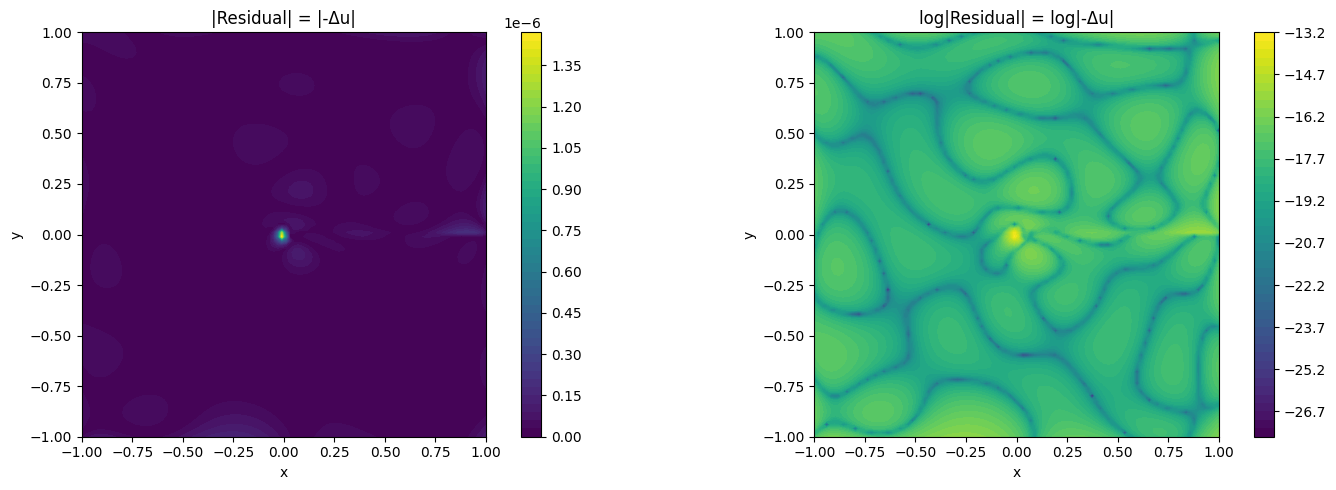

In [6]:
def eval_u(model, x, y):
    phi = compute_phi(x, y)
    inp = torch.cat([x, y, phi], dim=1)
    return model(inp)

def make_grid(N=100):
    x = torch.linspace(X_MIN, X_MAX, N)
    y = torch.linspace(Y_MIN, Y_MAX, N)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    return X, Y

X, Y = make_grid(100)

xg = X.reshape(-1, 1).to(device)
yg = Y.reshape(-1, 1).to(device)

with torch.no_grad():
    Ug = eval_u(model, xg, yg)

U = Ug.reshape(X.shape).cpu().numpy()
Xn = X.cpu().numpy()
Yn = Y.cpu().numpy()

lap_u = laplace_u(model, xg, yg)
residual = -lap_u
abs_residual = torch.abs(residual).detach().cpu().numpy()
log_abs_residual = torch.log(torch.abs(residual)).detach().cpu().numpy()
abs_residual = abs_residual.reshape(X.shape)
log_abs_residual = log_abs_residual.reshape(X.shape)

fig, axs = plt.subplots(1, 2, figsize=(15,5))

im0 = axs[0].contourf(X, Y, abs_residual, 50, cmap='viridis')
fig.colorbar(im0, ax=axs[0])
axs[0].set_title('|Residual| = |-Δu|')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_aspect('equal')

im1 = axs[1].contourf(X, Y, log_abs_residual, 50, cmap='viridis')
fig.colorbar(im1, ax=axs[1])
axs[1].set_title('log|Residual| = log|-Δu|')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

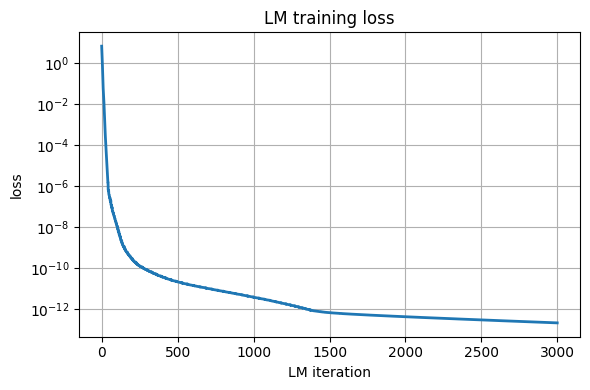

In [7]:
plt.figure(figsize=(6,4))
plt.semilogy(loss_history, lw=2)
plt.xlabel("LM iteration")
plt.ylabel("loss")
plt.title("LM training loss")
plt.grid(True)
plt.tight_layout()
plt.show()
